In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/fluoroscopy_data.csv")

In [3]:
df.head()

,Procedure_ID,Procedure_Type,Patient_Age,Fluoroscopy_Time_min,DAP_Gy_cm2,Air_Kerma_mGy,Operator,Date
0,FL0001,Coronary Angiography,21,26.3,86.5,1708,Dr. A,2024-10-06
1,FL0002,Peripheral Angiography,72,2.6,9.6,271,Dr. B,2024-10-14
2,FL0003,Peripheral Angiography,71,8.9,46.1,835,Dr. D,2024-03-22
3,FL0004,ERCP,53,6.7,39.4,771,Dr. C,2024-02-19
4,FL0005,ERCP,51,28.5,139.0,4801,Dr. A,2024-07-12


In [4]:
df.shape

(300, 8)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Procedure_ID          300 non-null    str    
 1   Procedure_Type        300 non-null    str    
 2   Patient_Age           300 non-null    int64  
 3   Fluoroscopy_Time_min  300 non-null    float64
 4   DAP_Gy_cm2            300 non-null    float64
 5   Air_Kerma_mGy         300 non-null    int64  
 6   Operator              300 non-null    str    
 7   Date                  300 non-null    str    
dtypes: float64(2), int64(2), str(4)
memory usage: 18.9 KB


In [6]:
df.describe()

,Patient_Age,Fluoroscopy_Time_min,DAP_Gy_cm2,Air_Kerma_mGy
count,300.000000,300.000000,300.000000,300.000000
mean,55.140000,17.806000,75.057000,2014.826667
std,20.745965,9.376361,40.708895,1159.710025
min,18.000000,1.700000,6.400000,144.000000
25%,37.000000,9.575000,43.450000,1108.250000
50%,56.000000,17.000000,70.850000,1768.500000
75%,73.000000,25.950000,99.075000,2781.750000
max,90.000000,35.000000,180.800000,5474.000000


In [7]:
df.isnull().sum()

Procedure_ID            0
Procedure_Type          0
Patient_Age             0
Fluoroscopy_Time_min    0
DAP_Gy_cm2              0
Air_Kerma_mGy           0
Operator                0
Date                    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

df.columns

In [9]:
df.columns

Index(['Procedure_ID', 'Procedure_Type', 'Patient_Age', 'Fluoroscopy_Time_min',
       'DAP_Gy_cm2', 'Air_Kerma_mGy', 'Operator', 'Date'],
      dtype='str')

In [10]:
df["Procedure_Type"].value_counts()

Procedure_Type
Peripheral Angiography    71
Barium Swallow            66
Coronary Angiography      62
Coronary Angioplasty      58
ERCP                      43
Name: count, dtype: int64

In [11]:
df["Procedure_Type"].unique()

<StringArray>
[  'Coronary Angiography', 'Peripheral Angiography',                   'ERCP',
         'Barium Swallow',   'Coronary Angioplasty']
Length: 5, dtype: str

In [12]:
df["DAP_Gy_cm2"].mean()

np.float64(75.057)

In [13]:
df ["Air_Kerma_mGy"].mean()

np.float64(2014.8266666666666)

In [14]:
import matplotlib.pyplot as plt

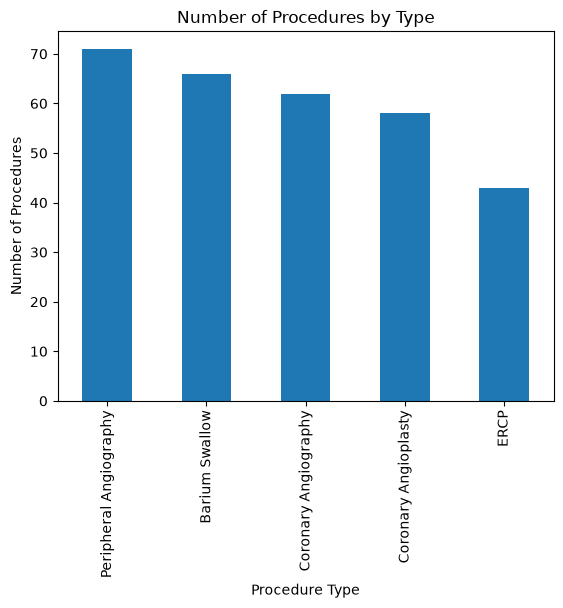

In [15]:
df["Procedure_Type"].value_counts().plot(kind="bar")
plt.title("Number of Procedures by Type")
plt.xlabel("Procedure Type")
plt.ylabel("Number of Procedures")
plt.savefig("../images/procedure_types.png", dpi=300)
plt.show()

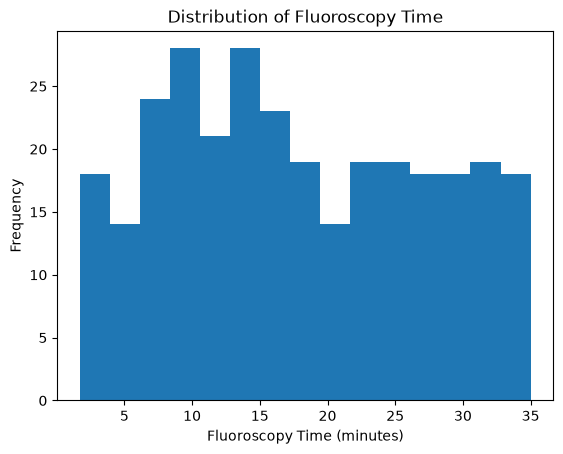

In [16]:
df["Fluoroscopy_Time_min"].plot(kind="hist", bins=15)
plt.title("Distribution of Fluoroscopy Time")
plt.xlabel("Fluoroscopy Time (minutes)")
plt.ylabel("Frequency")
plt.show()

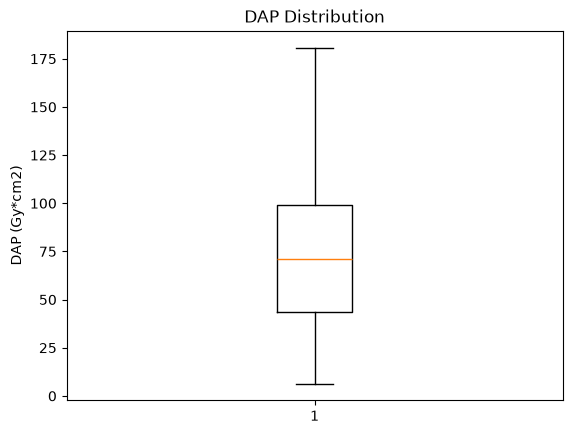

In [17]:
plt.boxplot(df["DAP_Gy_cm2"])
plt.title("DAP Distribution")
plt.ylabel("DAP (Gy*cm2)")
plt.show()

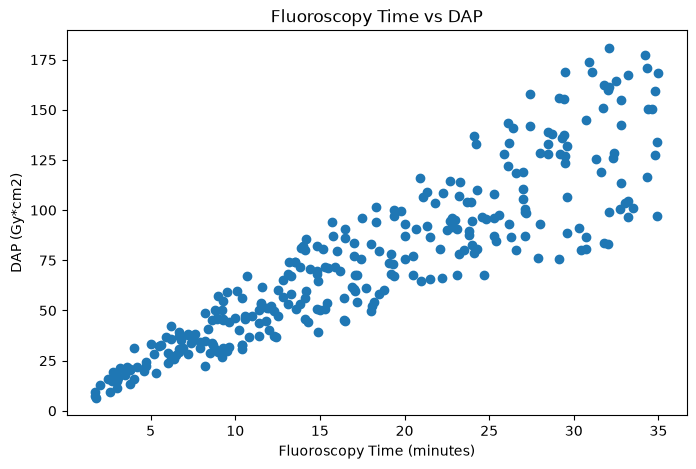

In [18]:
plt.figure(figsize=(8,5))
plt.scatter(df["Fluoroscopy_Time_min"], df["DAP_Gy_cm2"])
plt.title("Fluoroscopy Time vs DAP")
plt.xlabel("Fluoroscopy Time (minutes)")
plt.ylabel("DAP (Gy*cm2)")
plt.savefig("../images/scatter_time_vs_dap.png", dpi=300)
plt.show()

In [19]:
df["Fluoroscopy_Time_min"].corr(df["DAP_Gy_cm2"])

np.float64(0.9004428913047998)

In [20]:
df.groupby("Procedure_Type")["DAP_Gy_cm2"].mean()

Procedure_Type
Barium Swallow            71.890909
Coronary Angiography      73.459677
Coronary Angioplasty      76.627586
ERCP                      82.418605
Peripheral Angiography    73.653521
Name: DAP_Gy_cm2, dtype: float64

In [21]:
df.groupby("Procedure_Type")["DAP_Gy_cm2"].mean().sort_values(ascending=False)

Procedure_Type
ERCP                      82.418605
Coronary Angioplasty      76.627586
Peripheral Angiography    73.653521
Coronary Angiography      73.459677
Barium Swallow            71.890909
Name: DAP_Gy_cm2, dtype: float64

In [22]:
df.groupby("Procedure_Type")["Fluoroscopy_Time_min"].mean().sort_values(ascending=False)

Procedure_Type
ERCP                      19.204651
Peripheral Angiography    18.246479
Coronary Angiography      17.451613
Barium Swallow            17.322727
Coronary Angioplasty      17.158621
Name: Fluoroscopy_Time_min, dtype: float64

In [23]:
df["Procedure_Type"].value_counts()

Procedure_Type
Peripheral Angiography    71
Barium Swallow            66
Coronary Angiography      62
Coronary Angioplasty      58
ERCP                      43
Name: count, dtype: int64

In [24]:
df.groupby("Operator")["DAP_Gy_cm2"].mean().sort_values(ascending=False)

Operator
Dr. A    76.611236
Dr. B    75.296970
Dr. C    74.189873
Dr. D    73.759091
Name: DAP_Gy_cm2, dtype: float64

In [25]:
summary = df.groupby("Procedure_Type").agg({
    "DAP_Gy_cm2": "mean",
    "Fluoroscopy_Time_min": "mean",
    "Patient_Age": "mean"
})

summary

,DAP_Gy_cm2,Fluoroscopy_Time_min,Patient_Age
Procedure_Type,,,
Barium Swallow,71.890909,17.322727,55.090909
Coronary Angiography,73.459677,17.451613,56.112903
Coronary Angioplasty,76.627586,17.158621,54.810345
ERCP,82.418605,19.204651,55.000000
Peripheral Angiography,73.653521,18.246479,54.690141


In [26]:
df.columns

Index(['Procedure_ID', 'Procedure_Type', 'Patient_Age', 'Fluoroscopy_Time_min',
       'DAP_Gy_cm2', 'Air_Kerma_mGy', 'Operator', 'Date'],
      dtype='str')

In [29]:
df=df.rename(columns={"Procedure_Type":"Procedure", "Fluoroscopy_Time_min":"Fluoroscopy_Time", "Dap_Gy_cm2":"DAP" , "Air_Kerma_mGy":"Air_Kerma"})
df.head()

,Procedure_ID,Procedure,Patient_Age,Fluoroscopy_Time,DAP_Gy_cm2,Air_Kerma,Operator,Date
0,FL0001,Coronary Angiography,21,26.3,86.5,1708,Dr. A,2024-10-06
1,FL0002,Peripheral Angiography,72,2.6,9.6,271,Dr. B,2024-10-14
2,FL0003,Peripheral Angiography,71,8.9,46.1,835,Dr. D,2024-03-22
3,FL0004,ERCP,53,6.7,39.4,771,Dr. C,2024-02-19
4,FL0005,ERCP,51,28.5,139.0,4801,Dr. A,2024-07-12


In [30]:
df.to_csv("../data/cleaned_data.csv", index=False)

In [32]:
df_clean=pd.read_csv("../data/cleaned_data.csv")
df_clean.head()

,Procedure_ID,Procedure,Patient_Age,Fluoroscopy_Time,DAP_Gy_cm2,Air_Kerma,Operator,Date
0,FL0001,Coronary Angiography,21,26.3,86.5,1708,Dr. A,2024-10-06
1,FL0002,Peripheral Angiography,72,2.6,9.6,271,Dr. B,2024-10-14
2,FL0003,Peripheral Angiography,71,8.9,46.1,835,Dr. D,2024-03-22
3,FL0004,ERCP,53,6.7,39.4,771,Dr. C,2024-02-19
4,FL0005,ERCP,51,28.5,139.0,4801,Dr. A,2024-07-12
